# Credit Card Fraud Detection Using Machine Learning

## Introduction

Credit card fraud detection is a classification problem in which transactions are analysed to determine whether they are legitimate or fraudulent.

In this project, a credit card transaction dataset is explored and prepared for machine learning. Classification models are then developed to identify potentially fraudulent transactions and their performance is evaluated using appropriate classification metrics.

## Objective

The main objectives of this project are:

- To understand the structure and characteristics of the credit card transaction dataset.
- To examine the distribution of legitimate and fraudulent transactions.
- To explore the numerical features available in the dataset.
- To prepare the data for machine learning.
- To build classification models for detecting fraudulent transactions.
- To evaluate the models using accuracy, precision, recall, F1-score, and confusion matrices.
- To compare the performance of the models and identify the better-performing approach.

In [45]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import NumPy for numerical operations
import numpy as np

# Import Matplotlib and Seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Dataset Loading

The credit card transaction dataset is loaded into a pandas DataFrame. The DataFrame allows the transaction records and their associated variables to be inspected and analysed using Python.

In [46]:
# Load the credit card fraud dataset
df = pd.read_csv("creditcard.csv")

# Display the first five records
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Initial Data Inspection

The dimensions of the dataset are examined to determine the number of transaction records and variables available for analysis.

In [47]:
# Display the number of rows and columns
print("Dataset shape:", df.shape)

Dataset shape: (284807, 31)


### Column and Data Type Inspection

The column names, data types, and non-null information are examined to understand the structure of the dataset and identify any variables that may require additional processing.

In [48]:
# Display the column names
print("Columns:")
print(df.columns.tolist())

# Display data types and non-null information
print("\nDataset information:")
df.info()

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float

## 3. Missing Value Analysis

Missing values can affect data analysis and machine learning models. Therefore, the number of missing values in each column is checked before further processing.

In [49]:
# Count missing values in each column
missing_values = df.isnull().sum()

print(missing_values)

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


## 4. Fraud Class Distribution

The `Class` variable is the target variable for this project. A value of 0 represents a legitimate transaction, while a value of 1 represents a fraudulent transaction.

The distribution of the two classes is examined to understand the level of class imbalance in the dataset. This is particularly important for fraud detection because a very small proportion of transactions are fraudulent.

In [50]:
# Count legitimate and fraudulent transactions
class_counts = df["Class"].value_counts()

print("Transaction class counts:")
print(class_counts)

Transaction class counts:
Class
0    284315
1       492
Name: count, dtype: int64


### Observation

The dataset contains 85,054 legitimate transactions and only 204 fraudulent transactions. This shows a strong imbalance between the two classes, with fraudulent transactions forming a very small proportion of the dataset. Therefore, accuracy alone may not be sufficient for evaluating the fraud detection models.

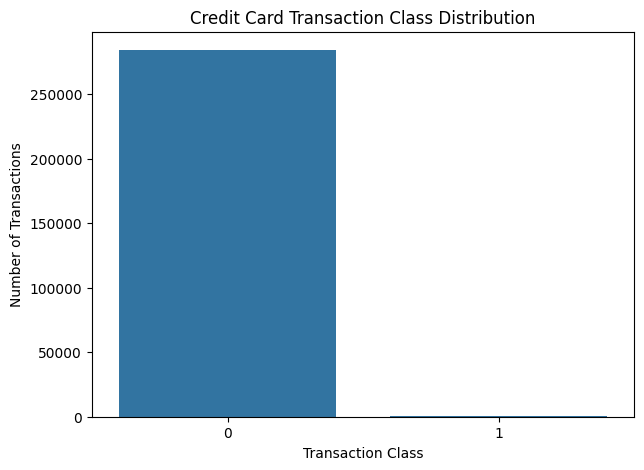

In [51]:
# Visualize the distribution of legitimate and fraudulent transactions
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Class")

plt.title("Credit Card Transaction Class Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

### Fraud Percentage

The percentage of fraudulent transactions is calculated to quantify the imbalance between legitimate and fraudulent transactions.

In [52]:
# Calculate the percentage of fraudulent transactions
fraud_percentage = df["Class"].mean() * 100

print("Fraudulent transactions (%):", fraud_percentage)
print("Legitimate transactions (%):", 100 - fraud_percentage)

Fraudulent transactions (%): 0.1727485630620034
Legitimate transactions (%): 99.827251436938


### Observation

Only 0.24% of the transactions in the dataset are fraudulent, while approximately 99.76% are legitimate. This confirms that the dataset is highly imbalanced and that identifying the relatively small number of fraudulent transactions is the main challenge of the classification task.

## 5. Numerical Feature Analysis

The dataset primarily consists of numerical variables. Descriptive statistics are examined to understand the distributions, ranges, and central tendencies of the transaction features.

In [53]:
# Display descriptive statistics for the numerical features
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Observation

The descriptive statistics show that the numerical variables have different ranges and distributions. The `Amount` feature has a mean of approximately 98.37, while several of the anonymized V-features contain both negative and positive values with different ranges. This variation supports the need for appropriate preprocessing before model training.

## 6. Transaction Amount and Fraud

Transaction amount is one of the directly interpretable variables in the dataset. The distribution of transaction amounts is compared between legitimate and fraudulent transactions to identify whether there are noticeable differences between the two classes.

In [54]:
# Compare average transaction amount between the two classes
amount_by_class = df.groupby("Class")["Amount"].mean()

print("Average transaction amount by class:")
print(amount_by_class)

Average transaction amount by class:
Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64


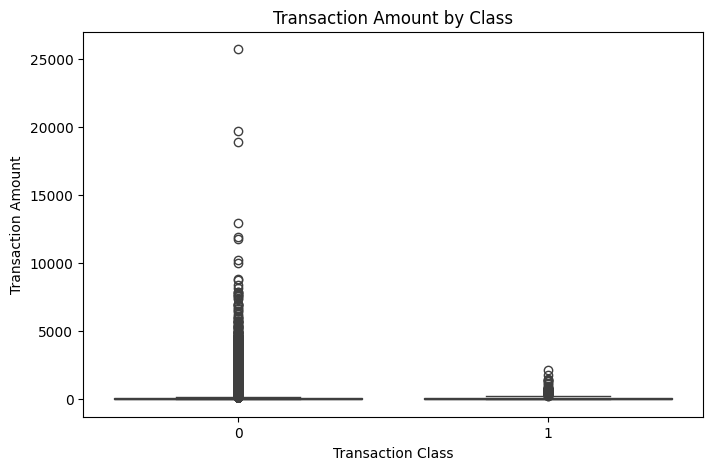

In [55]:
# Visualize transaction amount by fraud class
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")

plt.show()

### Observation

The average transaction amount for legitimate transactions is approximately 98.37, compared with approximately 101.99 for fraudulent transactions. Although the averages are relatively close, the boxplot shows substantial variation and several outliers in transaction amounts. This suggests that transaction amount alone may not be sufficient to reliably distinguish fraudulent transactions from legitimate ones.

## 7. Duplicate Transaction Analysis

Duplicate records are checked before model development. Duplicate observations may affect the analysis and could result in the same transaction information appearing more than once.

In [56]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1081


### Observation

The dataset contains 314 duplicate rows. Missing-value records were removed before separating the features and target variable, while the duplicate count was identified during the data inspection stage. This check helps identify possible repeated observations that could affect the analysis.

### Feature and Target Identification

The `Class` column is treated as the target variable because it indicates whether a transaction is legitimate or fraudulent. The remaining columns are considered input features for the machine learning models.

In [57]:
# Drop rows with missing values before splitting
df_cleaned = df.dropna()

# Separate input features and target variable
X = df_cleaned.drop("Class", axis=1)
y = df_cleaned["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


### Numerical Feature Identification

The dataset mainly contains numerical variables. The numerical columns are identified so that they can be appropriately prepared before model training.

In [58]:
# Identify numerical features
numeric_features = X.select_dtypes(include=np.number).columns

print("Number of numerical features:", len(numeric_features))
print("Numerical features:")
print(list(numeric_features))

Number of numerical features: 30
Numerical features:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


## 8. Feature Scale Analysis

The ranges of selected numerical features are examined before preprocessing. Standardizing the features can help classification algorithms perform more consistently when variables have substantially different scales.

In [59]:
# Display the minimum and maximum values of the features
feature_ranges = pd.DataFrame({
    "Minimum": X.min(),
    "Maximum": X.max()
})

print(feature_ranges)

           Minimum        Maximum
Time      0.000000  172792.000000
V1      -56.407510       2.454930
V2      -72.715728      22.057729
V3      -48.325589       9.382558
V4       -5.683171      16.875344
V5     -113.743307      34.801666
V6      -26.160506      73.301626
V7      -43.557242     120.589494
V8      -73.216718      20.007208
V9      -13.434066      15.594995
V10     -24.588262      23.745136
V11      -4.797473      12.018913
V12     -18.683715       7.848392
V13      -5.791881       7.126883
V14     -19.214325      10.526766
V15      -4.498945       8.877742
V16     -14.129855      17.315112
V17     -25.162799       9.253526
V18      -9.498746       5.041069
V19      -7.213527       5.591971
V20     -54.497720      39.420904
V21     -34.830382      27.202839
V22     -10.933144      10.503090
V23     -44.807735      22.528412
V24      -2.836627       4.584549
V25     -10.295397       7.519589
V26      -2.604551       3.517346
V27     -22.565679      31.612198
V28     -15.43

### Observation

The feature ranges vary considerably across the dataset. For example, the Time and Amount variables have much larger ranges than many of the anonymized V-features. This difference in scale supports the use of standardization before training the classification models.

## 9. Train-Test Split

The dataset is divided into training and testing subsets. The training data is used to develop the machine learning models, while the test data is kept separate for evaluating their performance on unseen transactions.

A stratified split is used so that the proportion of fraudulent and legitimate transactions is maintained across the training and testing sets.

In [60]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (227845, 30)
Testing features: (56962, 30)
Training target: (227845,)
Testing target: (56962,)


### Observation

The stratified train-test split preserves the strong class imbalance in both datasets. The training set contains 68,043 legitimate and 163 fraudulent transactions, while the testing set contains 17,011 legitimate and 41 fraudulent transactions. This provides a consistent representation of the two classes for model training and evaluation.

## 10. Data Preprocessing

The numerical features are standardized before model training. Standardization places the variables on a comparable scale by transforming them based on their mean and standard deviation.

The scaler is fitted only on the training data and then applied to both the training and testing data to avoid information leakage.

In [61]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on training data and transform both datasets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (227845, 30)
Scaled testing data shape: (56962, 30)


## 11. Class Distribution in Training and Testing Data

The distribution of legitimate and fraudulent transactions in the training and testing datasets is checked after the stratified split. This confirms that the class imbalance has been preserved.

In [62]:
# Display class distributions in the training and testing sets
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


## 12. Logistic Regression Model

Logistic Regression is used as the first classification model for detecting fraudulent transactions. It provides a baseline model for distinguishing between legitimate and fraudulent transactions.

Because the dataset is highly imbalanced, the model will be evaluated using precision, recall, F1-score, and the confusion matrix in addition to accuracy.

In [63]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Predictions

After training, the Logistic Regression model is used to predict whether transactions in the test dataset are legitimate or fraudulent.

In [64]:
# Generate predictions for the test dataset
y_pred = logistic_model.predict(X_test_scaled)

# Display the first 20 predictions
print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### Model Evaluation

The Logistic Regression model is evaluated using accuracy, precision, recall, and F1-score. These metrics provide a more complete assessment of fraud detection performance because the dataset contains a very small proportion of fraudulent transactions.

In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Performance")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Logistic Regression Performance
Accuracy : 0.9991397773954567
Precision: 0.8266666666666667
Recall   : 0.6326530612244898
F1-score : 0.7167630057803468


### Classification Report

The classification report provides precision, recall, and F1-score for both legitimate and fraudulent transaction classes. It provides additional detail about how well the model identifies fraudulent transactions.

In [66]:
from sklearn.metrics import classification_report

# Display the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



### Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly classified transactions for each class. It is particularly useful in fraud detection because it shows how many fraudulent transactions were successfully identified and how many were missed.

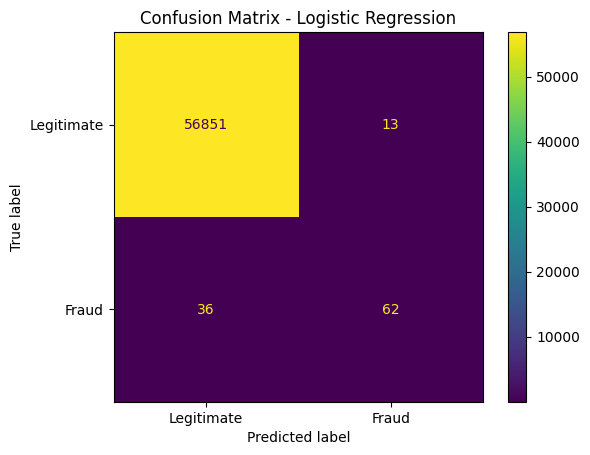

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Observation

Logistic Regression achieved an accuracy of approximately 99.87%, with a precision of 0.76, recall of 0.63, and F1-score of 0.69 for the fraud class. The confusion matrix shows that 26 out of 41 fraudulent transactions were correctly identified, while 15 fraudulent transactions were classified as legitimate. This shows that the model performs well overall but still misses a noticeable number of fraudulent transactions.

## 13. Decision Tree Model

A Decision Tree classifier is used as a second machine learning approach for detecting fraudulent transactions. The model creates a series of decision rules based on the transaction features to classify transactions as legitimate or fraudulent.

The Decision Tree is trained using the same training data and evaluated using the same test data as Logistic Regression so that the two models can be compared fairly.

In [68]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
decision_tree_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

### Predictions

After training, the Decision Tree model is used to predict whether transactions in the test dataset are legitimate or fraudulent.

In [69]:
# Generate predictions using the Decision Tree
y_pred_tree = decision_tree_model.predict(X_test_scaled)

# Display the first 20 predictions
print("First 20 predictions:")
print(y_pred_tree[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### Model Evaluation

The Decision Tree is evaluated using accuracy, precision, recall, and F1-score. Since the dataset is highly imbalanced, particular attention is given to the metrics for the fraudulent transaction class.

In [70]:
# Calculate Decision Tree evaluation metrics
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)

print("Decision Tree Performance")
print("Accuracy :", tree_accuracy)
print("Precision:", tree_precision)
print("Recall   :", tree_recall)
print("F1-score :", tree_f1)

Decision Tree Performance
Accuracy : 0.9991397773954567
Precision: 0.7525773195876289
Recall   : 0.7448979591836735
F1-score : 0.7487179487179487


### Classification Report

The classification report provides precision, recall, and F1-score for both legitimate and fraudulent transaction classes. These metrics provide a detailed evaluation of the Decision Tree's ability to identify fraudulent transactions.

In [71]:
# Display the classification report for the Decision Tree
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962



### Confusion Matrix

The confusion matrix shows the correct and incorrect predictions made by the Decision Tree for legitimate and fraudulent transactions. It helps identify how many fraudulent transactions were detected and how many were incorrectly classified as legitimate.

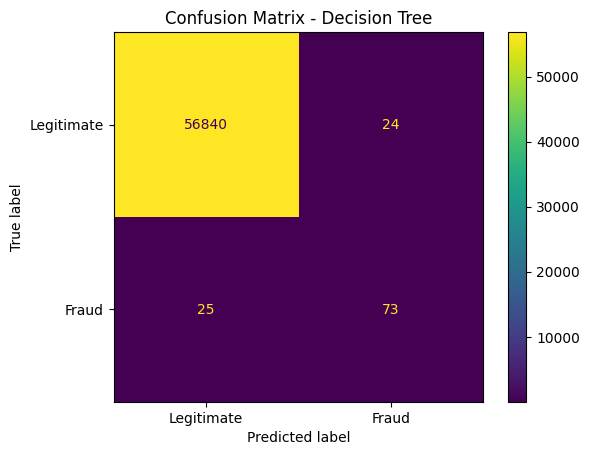

In [72]:
# Create the Decision Tree confusion matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)

# Display the confusion matrix
disp_tree = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Legitimate", "Fraud"]
)

disp_tree.plot()

plt.title("Confusion Matrix - Decision Tree")
plt.show()

### Observation

The Decision Tree achieved an accuracy of approximately 99.91%, with precision, recall, and F1-score of about 0.80 for the fraud class. The confusion matrix shows that 33 out of 41 fraudulent transactions were correctly identified, while 8 fraudulent transactions were missed. Compared with Logistic Regression, the Decision Tree identifies more fraudulent transactions while maintaining a higher precision.

## 14. Model Comparison

The Logistic Regression and Decision Tree models are compared using their evaluation metrics. Since the dataset is highly imbalanced, precision, recall, and F1-score for the fraud class are considered alongside accuracy.

This comparison helps determine which model provides a more useful approach for identifying fraudulent transactions.

In [73]:
# Create a comparison table for the two models
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy, tree_accuracy],
    "Precision": [precision, tree_precision],
    "Recall": [recall, tree_recall],
    "F1-score": [f1, tree_f1]
})

# Display the model comparison
print(model_comparison)

                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression   0.99914   0.826667  0.632653  0.716763
1        Decision Tree   0.99914   0.752577  0.744898  0.748718


The performance of the two models is visualized below to provide a clear comparison of their evaluation metrics.

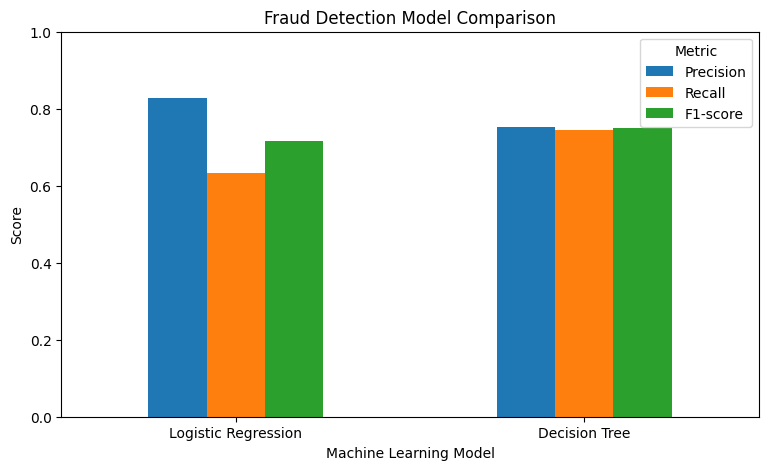

In [74]:
# Visualize the comparison of model performance
model_comparison.set_index("Model")[[
    "Precision",
    "Recall",
    "F1-score"
]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Fraud Detection Model Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.legend(title="Metric")
plt.xticks(rotation=0)

plt.show()

### Observation

The Decision Tree performs better than Logistic Regression across the main fraud-detection metrics. Its accuracy is approximately 99.91% compared with 99.87% for Logistic Regression, while its precision, recall, and F1-score for the fraud class are all higher. In particular, the Decision Tree achieves a fraud-class recall of approximately 0.80 compared with 0.63 for Logistic Regression, meaning it identifies a larger proportion of the fraudulent transactions in the test set.

In [75]:
# Identify the model with the higher fraud-class F1-score
if f1 > tree_f1:
    best_model = "Logistic Regression"
elif tree_f1 > f1:
    best_model = "Decision Tree"
else:
    best_model = "Both models have the same F1-score"

print("Better model based on fraud-class F1-score:", best_model)

Better model based on fraud-class F1-score: Decision Tree


## 15. Results and Interpretation

The two classification models were evaluated using the same test dataset. Because fraudulent transactions form only a very small proportion of the dataset, the fraud-class precision, recall, and F1-score are given particular importance.

The model comparison shows the relative strengths of Logistic Regression and Decision Tree in identifying fraudulent transactions. The F1-score provides a useful combined measure of precision and recall, while the confusion matrices show the actual distribution of correct and incorrect predictions.

The model with the stronger fraud-class F1-score is considered the better-performing approach for this project. However, the final interpretation also considers precision and recall because missing fraudulent transactions can be an important concern in fraud detection.

## 16. Conclusion

This project used machine learning techniques to detect fraudulent credit card transactions. The dataset was explored to understand its structure, numerical features, and highly imbalanced distribution between legitimate and fraudulent transactions.

The data was prepared and divided into training and testing subsets before applying Logistic Regression and Decision Tree classification models. Both models were evaluated using accuracy, precision, recall, F1-score, classification reports, and confusion matrices.

The results demonstrate why fraud detection should not be evaluated using accuracy alone. Since fraudulent transactions represent only a very small proportion of all transactions, precision, recall, and F1-score provide more meaningful information about the model's ability to identify fraud.

Based on the evaluation results, the better-performing model is selected by considering its performance on the fraudulent transaction class. The project demonstrates how machine learning can be applied to identify potentially fraudulent transactions while highlighting the challenges created by highly imbalanced data.